In [1]:
import os
import glob
import numpy as np

import sys

import subprocess
import itertools
from pathlib import Path

In [2]:
WORKING_DIR = Path.cwd().parent

In [3]:
num_vr_stations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
num_bg_stations = 2
enable_qos = False
enable_aggregation = False

rng = 1

In [4]:
combinations = list(itertools.product(num_vr_stations, [num_bg_stations], [enable_qos], [enable_aggregation]))
total = len(combinations)

In [5]:
data_dir = WORKING_DIR / "jows"
data_dir.mkdir(exist_ok=True)
TEST_DIR = data_dir / "degradation_point"
TEST_DIR.mkdir(exist_ok=True)

In [6]:
#With BG Traffic, no QoS, no Aggregation
TEST_DIR_BG = TEST_DIR / "with_bg_traffic"
TEST_DIR_BG.mkdir(exist_ok=True)

In [8]:
rng_seeds = list(range(1, 11))   # 1..10

for rng_v in rng_seeds:
    for run_idx, (num_vr, num_bg, qos, agg) in enumerate(combinations, start=1):
        prefix = f"jows_vr_{int(num_vr)}_bg_{str(num_bg)}_qos_{str(qos)}_agg_{str(agg)}_rng_{rng_v}"

        # Skip jeśli plik już istnieje (oszczędza czas przy ponownym uruchamianiu)
        out_csv = TEST_DIR_BG / f"{prefix}.csv"
        if out_csv.exists():
            print(f"[rng={rng_v}] skip {prefix} (already exists)")
            continue

        cmd = [
            "./ns3",
            "run",
            (
                f'projekt_vr '
                f'--vrStations={int(num_vr)} '
                f'--RngRun={rng_v} '
                f'--bgStations={num_bg} '
                f'--enableQos={str(qos).lower()} '
                f'--enableAggregation={str(agg).lower()} '
                f'--outputDir={str(TEST_DIR_BG)} '
                f'--csvFileName={prefix}.csv '
                f'--xmlFileName={prefix}.xml '
            )
        ]

        print(f"[rng={rng_v}] [{run_idx}/{total}] vr={num_vr} bg={num_bg} qos={qos} agg={agg}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=WORKING_DIR)
        if result.returncode != 0:
            print(f"  ERROR (exit {result.returncode}): {result.stderr}")
        else:
            print("  OK")

print("\nAll runs complete.")

[rng=1] [1/10] vr=1 bg=2 qos=False agg=False
  OK
[rng=1] [2/10] vr=2 bg=2 qos=False agg=False
  OK
[rng=1] [3/10] vr=3 bg=2 qos=False agg=False
  OK
[rng=1] [4/10] vr=4 bg=2 qos=False agg=False
  OK
[rng=1] [5/10] vr=5 bg=2 qos=False agg=False
  OK
[rng=1] [6/10] vr=6 bg=2 qos=False agg=False
  OK
[rng=1] [7/10] vr=7 bg=2 qos=False agg=False
  OK
[rng=1] [8/10] vr=8 bg=2 qos=False agg=False
  OK
[rng=1] [9/10] vr=9 bg=2 qos=False agg=False
  OK
[rng=1] [10/10] vr=10 bg=2 qos=False agg=False
  OK
[rng=2] [1/10] vr=1 bg=2 qos=False agg=False
  OK
[rng=2] [2/10] vr=2 bg=2 qos=False agg=False
  OK
[rng=2] [3/10] vr=3 bg=2 qos=False agg=False
  OK
[rng=2] [4/10] vr=4 bg=2 qos=False agg=False
  OK
[rng=2] [5/10] vr=5 bg=2 qos=False agg=False
  OK
[rng=2] [6/10] vr=6 bg=2 qos=False agg=False
  OK
[rng=2] [7/10] vr=7 bg=2 qos=False agg=False
  OK
[rng=2] [8/10] vr=8 bg=2 qos=False agg=False
  OK
[rng=2] [9/10] vr=9 bg=2 qos=False agg=False
  OK
[rng=2] [10/10] vr=10 bg=2 qos=False agg=False
 

In [9]:
#Without BG Traffic, no QoS, no Aggregation
TEST_DIR_NO_BG = TEST_DIR / "without_bg_traffic"
TEST_DIR_NO_BG.mkdir(exist_ok=True)

In [10]:
num_bg_stations = 0
combinations = list(itertools.product(num_vr_stations, [num_bg_stations], [enable_qos], [enable_aggregation]))
total = len(combinations)

In [11]:
rng_seeds = list(range(1, 11))   # 1..10

for rng_v in rng_seeds:
    for run_idx, (num_vr, num_bg, qos, agg) in enumerate(combinations, start=1):
        prefix = f"jows_vr_{int(num_vr)}_bg_{str(num_bg)}_qos_{str(qos)}_agg_{str(agg)}_rng_{rng_v}"

        # Skip jeśli plik już istnieje (oszczędza czas przy ponownym uruchamianiu)
        out_csv = TEST_DIR_NO_BG / f"{prefix}.csv"
        if out_csv.exists():
            print(f"[rng={rng_v}] skip {prefix} (already exists)")
            continue

        cmd = [
            "./ns3",
            "run",
            (
                f'projekt_vr '
                f'--vrStations={int(num_vr)} '
                f'--RngRun={rng_v} '
                f'--bgStations={num_bg} '
                f'--enableQos={str(qos).lower()} '
                f'--enableAggregation={str(agg).lower()} '
                f'--outputDir={str(TEST_DIR_NO_BG)} '
                f'--csvFileName={prefix}.csv '
                f'--xmlFileName={prefix}.xml '
            )
        ]

        print(f"[rng={rng_v}] [{run_idx}/{total}] vr={num_vr} bg={num_bg} qos={qos} agg={agg}")
        result = subprocess.run(cmd, capture_output=True, text=True, cwd=WORKING_DIR)
        if result.returncode != 0:
            print(f"  ERROR (exit {result.returncode}): {result.stderr}")
        else:
            print("  OK")

print("\nAll runs complete.")

[rng=1] [1/10] vr=1 bg=0 qos=False agg=False
  OK
[rng=1] [2/10] vr=2 bg=0 qos=False agg=False
  OK
[rng=1] [3/10] vr=3 bg=0 qos=False agg=False
  OK
[rng=1] [4/10] vr=4 bg=0 qos=False agg=False
  OK
[rng=1] [5/10] vr=5 bg=0 qos=False agg=False
  OK
[rng=1] [6/10] vr=6 bg=0 qos=False agg=False
  OK
[rng=1] [7/10] vr=7 bg=0 qos=False agg=False
  OK
[rng=1] [8/10] vr=8 bg=0 qos=False agg=False
  OK
[rng=1] [9/10] vr=9 bg=0 qos=False agg=False
  OK
[rng=1] [10/10] vr=10 bg=0 qos=False agg=False
  OK
[rng=2] [1/10] vr=1 bg=0 qos=False agg=False
  OK
[rng=2] [2/10] vr=2 bg=0 qos=False agg=False
  OK
[rng=2] [3/10] vr=3 bg=0 qos=False agg=False
  OK
[rng=2] [4/10] vr=4 bg=0 qos=False agg=False
  OK
[rng=2] [5/10] vr=5 bg=0 qos=False agg=False
  OK
[rng=2] [6/10] vr=6 bg=0 qos=False agg=False
  OK
[rng=2] [7/10] vr=7 bg=0 qos=False agg=False
  OK
[rng=2] [8/10] vr=8 bg=0 qos=False agg=False
  OK
[rng=2] [9/10] vr=9 bg=0 qos=False agg=False
  OK
[rng=2] [10/10] vr=10 bg=0 qos=False agg=False
 

In [7]:
import pandas as pd

In [8]:
import glob
import re

files = glob.glob("degradation_point/**/*.csv", recursive=True)

raw_rows = []

for f in files:
    name = os.path.basename(f)
    m = re.match(
        r"jows_vr_(\d+)_bg_(\d+)_qos_(True|False)_agg_(True|False)_rng_(\d+)\.csv",
        name,
    )
    if not m:
        print(f"Skipping (unrecognized name): {name}")
        continue

    n_vr  = int(m.group(1))
    n_bg  = int(m.group(2))
    qos   = m.group(3) == "True"
    agg   = m.group(4) == "True"
    rng_v = int(m.group(5))

    df = pd.read_csv(f)
    vr_df = df[df["Type"] == "VR UDP"]
    bg_df = df[df["Type"] == "background TCP"]

    def aggregate(d):
        if len(d) == 0:
            return None
        tx = d["TxPackets"].sum()
        rx = d["RxPackets"].sum()
        lost = d["LostPackets"].sum() if "LostPackets" in d.columns else (tx - rx)
        return {
            "tx_packets":      tx,
            "rx_packets":      rx,
            "lost_packets":    lost,
            "loss_ratio":      lost / tx if tx > 0 else 0.0,
            "throughput_mbps": d["ThroughputMbps"].sum(),
            "delay_ms":        d["AvgDelayMs"].mean(),
            "jitter_ms":       d["AvgJitterMs"].mean(),
        }

    vr_stats = aggregate(vr_df)
    bg_stats = aggregate(bg_df)

    raw_rows.append({
        "n_vr": n_vr, "n_bg": n_bg, "bg": 1 if n_bg > 0 else 0,
        "qos": qos, "agg": agg, "rng": rng_v,
        "vr_loss":       vr_stats["loss_ratio"]      if vr_stats else None,
        "vr_delay":      vr_stats["delay_ms"]        if vr_stats else None,
        "vr_jitter":     vr_stats["jitter_ms"]       if vr_stats else None,
        "vr_throughput": vr_stats["throughput_mbps"] if vr_stats else None,
        "bg_throughput": bg_stats["throughput_mbps"] if bg_stats else None,
        "bg_delay":      bg_stats["delay_ms"]        if bg_stats else None,
    })

raw = pd.DataFrame(raw_rows)
raw["vr_throughput_per_station"] = raw["vr_throughput"] / raw["n_vr"]
raw["vr_loss_pct"] = raw["vr_loss"] * 100

print(f"Loaded {len(raw)} runs across {raw['rng'].nunique()} seeds")
print(f"Per scenario × n_vr count:")
print(raw.groupby(["bg", "n_vr"]).size().unstack(fill_value=0))

# === Agregacja: mean + std + 95% CI po seedach ===
metrics = ["vr_loss", "vr_loss_pct", "vr_delay", "vr_jitter",
           "vr_throughput", "vr_throughput_per_station"]

agg_dict = {}
for m_ in metrics:
    agg_dict[f"{m_}_mean"] = (m_, "mean")
    agg_dict[f"{m_}_std"]  = (m_, "std")
    agg_dict[f"{m_}_n"]    = (m_, "count")

res = raw.groupby(["bg", "n_vr"]).agg(**agg_dict).reset_index()

# 95% CI z rozkładu t (dla małej próby n=10 lepsze niż 1.96)
from scipy import stats as scipy_stats
for m_ in metrics:
    n = res[f"{m_}_n"]
    se = res[f"{m_}_std"] / np.sqrt(n)
    t_crit = scipy_stats.t.ppf(0.975, df=n - 1)
    res[f"{m_}_ci95"] = t_crit * se

print("\n=== Aggregated (mean ± std over seeds) ===")
preview = res[["bg", "n_vr",
               "vr_throughput_per_station_mean", "vr_throughput_per_station_std",
               "vr_delay_mean", "vr_delay_std",
               "vr_jitter_mean", "vr_jitter_std",
               "vr_loss_pct_mean", "vr_loss_pct_std"]]
print(preview.round(3).to_string(index=False))

Loaded 200 runs across 10 seeds
Per scenario × n_vr count:
n_vr  1   2   3   4   5   6   7   8   9   10
bg                                          
0     10  10  10  10  10  10  10  10  10  10
1     10  10  10  10  10  10  10  10  10  10

=== Aggregated (mean ± std over seeds) ===
 bg  n_vr  vr_throughput_per_station_mean  vr_throughput_per_station_std  vr_delay_mean  vr_delay_std  vr_jitter_mean  vr_jitter_std  vr_loss_pct_mean  vr_loss_pct_std
  0     1                          13.201                          0.002          0.094         0.007           0.004          0.004             0.014            0.012
  0     2                          13.200                          0.001          0.484         0.012           0.193          0.009             0.018            0.010
  0     3                          13.198                          0.002          0.553         0.006           0.329          0.007             0.028            0.013
  0     4                          13.197    

In [9]:
THRESHOLDS = {
    "throughput_per_station_mbps": 10.0,
    "delay_ms":                    20.0,
    "jitter_ms":                    5.0,
    "loss_ratio":                   0.01,
}

def degradation_points(scenario_df, scenario_label):
    sd = scenario_df.sort_values("n_vr")
    rows = []
    checks = [
        ("Throughput (≥10 Mb/s/st.)", "vr_throughput_per_station_mean",
         lambda s: s >= THRESHOLDS["throughput_per_station_mbps"]),
        ("Delay (<20 ms)",            "vr_delay_mean",
         lambda s: s <  THRESHOLDS["delay_ms"]),
        ("Jitter (<5 ms)",            "vr_jitter_mean",
         lambda s: s <  THRESHOLDS["jitter_ms"]),
        ("Loss (<1%)",                "vr_loss_mean",
         lambda s: s <  THRESHOLDS["loss_ratio"]),
    ]
    all_ok_mask = pd.Series(True, index=sd.index)
    for label, col, ok_fn in checks:
        ok = ok_fn(sd[col])
        all_ok_mask &= ok
        first_fail = sd[~ok]["n_vr"].min() if (~ok).any() else None
        max_ok     = sd[ ok]["n_vr"].max() if  ok.any()    else None
        rows.append({
            "Scenario": scenario_label, "Metric": label,
            "Max VR OK":     int(max_ok)     if pd.notna(max_ok)     else "—",
            "First failing": int(first_fail) if pd.notna(first_fail) else "never",
        })
    fa_first = sd[~all_ok_mask]["n_vr"].min() if (~all_ok_mask).any() else None
    fa_max   = sd[ all_ok_mask]["n_vr"].max() if  all_ok_mask.any()    else None
    rows.append({
        "Scenario": scenario_label, "Metric": "ALL",
        "Max VR OK":     int(fa_max)   if pd.notna(fa_max)   else "—",
        "First failing": int(fa_first) if pd.notna(fa_first) else "never",
    })
    return rows

summary = pd.DataFrame(
    degradation_points(res[res["bg"] == 0], "0 BG stations")
    + degradation_points(res[res["bg"] == 1], "2 BG stations")
)
print("\n=== Degradation point summary ===")
print(summary.to_string(index=False))


=== Degradation point summary ===
     Scenario                    Metric Max VR OK First failing
0 BG stations Throughput (≥10 Mb/s/st.)        10         never
0 BG stations            Delay (<20 ms)         8             9
0 BG stations            Jitter (<5 ms)        10         never
0 BG stations                Loss (<1%)        10         never
0 BG stations                       ALL         8             9
2 BG stations Throughput (≥10 Mb/s/st.)        10         never
2 BG stations            Delay (<20 ms)         —             1
2 BG stations            Jitter (<5 ms)        10         never
2 BG stations                Loss (<1%)         9            10
2 BG stations                       ALL         —             1


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

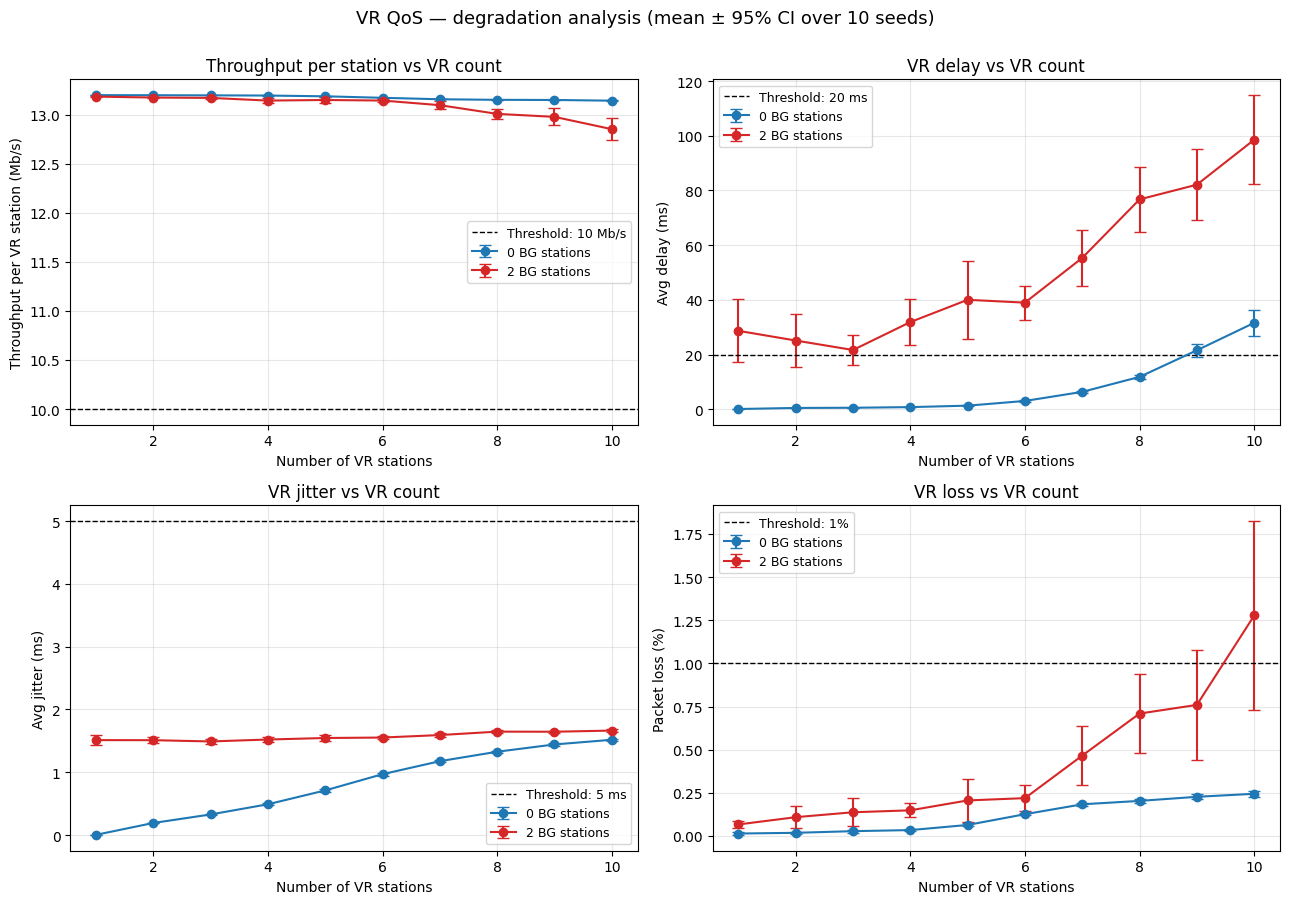

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

scenarios = [(0, "0 BG stations", "tab:blue"),
             (1, "2 BG stations", "tab:red")]

def plot_metric(ax, mean_col, ci_col, threshold, ylabel, title,
                threshold_label, comparison="<"):
    for bg_val, label, color in scenarios:
        sub = res[res["bg"] == bg_val].sort_values("n_vr")
        if sub.empty:
            continue
        ax.errorbar(sub["n_vr"], sub[mean_col], yerr=sub[ci_col],
                    fmt="-o", color=color, capsize=4, label=label,
                    markersize=6, linewidth=1.5)
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1,
               label=threshold_label)
    ax.set_xlabel("Number of VR stations")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="best")

plot_metric(axes[0, 0],
            "vr_throughput_per_station_mean", "vr_throughput_per_station_ci95",
            THRESHOLDS["throughput_per_station_mbps"],
            "Throughput per VR station (Mb/s)",
            "Throughput per station vs VR count",
            "Threshold: 10 Mb/s", comparison=">=")

plot_metric(axes[0, 1],
            "vr_delay_mean", "vr_delay_ci95",
            THRESHOLDS["delay_ms"],
            "Avg delay (ms)",
            "VR delay vs VR count",
            "Threshold: 20 ms")

plot_metric(axes[1, 0],
            "vr_jitter_mean", "vr_jitter_ci95",
            THRESHOLDS["jitter_ms"],
            "Avg jitter (ms)",
            "VR jitter vs VR count",
            "Threshold: 5 ms")

plot_metric(axes[1, 1],
            "vr_loss_pct_mean", "vr_loss_pct_ci95",
            THRESHOLDS["loss_ratio"] * 100,
            "Packet loss (%)",
            "VR loss vs VR count",
            "Threshold: 1%")

fig.suptitle("VR QoS — degradation analysis (mean ± 95% CI over 10 seeds)",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [13]:
fig.savefig(f'{TEST_DIR}/degradation_point.png', dpi=300, bbox_inches='tight')